In [1]:
from torchvision.datasets import MNIST
from torchvision.transforms import Compose
from torchvision.transforms import ToTensor
from torchvision.transforms import Normalize
from torch.utils.data import DataLoader
import torch
import os


# prepare the dataset
def prepare_data(path):
    """
    MNIST data preparation
    """
    # define standardization
    trans = Compose([ToTensor(), Normalize((0.5,), (1.0,))])
    # load dataset
    train = MNIST(path, train=True, download=True, transform=trans)
    test = MNIST(path, train=False, download=True, transform=trans)
    # prepare data loaders
    use_cuda = torch.cuda.is_available()
    # Heuristics for performant data loading
    num_workers = max(0, (os.cpu_count() or 0) - 1)
    pin = True if use_cuda else False

    train_kwargs = dict(
        batch_size=128,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin,
        drop_last=True,
    )
    test_kwargs = dict(
        batch_size=1024,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    if num_workers > 0:
        train_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))
        test_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

    train_dl = DataLoader(train, **train_kwargs)
    test_dl = DataLoader(test, **test_kwargs)
    return train_dl, test_dl


In [2]:
from torch.nn import Conv2d
from torch.nn import MaxPool2d
from torch.nn import Linear
from torch.nn import ReLU
from torch.nn import Module

from torch.nn.init import kaiming_uniform_
from torch.nn.init import xavier_uniform_

# model definition


class CNN(Module):
    # define model elements
    def __init__(self, n_channels):
        super(CNN, self).__init__()
        # input to first hidden layer
        self.hidden1 = Conv2d(n_channels, 32, (3, 3))
        kaiming_uniform_(self.hidden1.weight, nonlinearity='relu')
        self.act1 = ReLU()
        # first pooling layer
        self.pool1 = MaxPool2d((2, 2), stride=(2, 2))
        # second hidden layer
        self.hidden2 = Conv2d(32, 32, (3, 3))
        kaiming_uniform_(self.hidden2.weight, nonlinearity='relu')
        self.act2 = ReLU()
        # second pooling layer
        self.pool2 = MaxPool2d((2, 2), stride=(2, 2))
        # fully connected layer
        self.hidden3 = Linear(5*5*32, 100)
        kaiming_uniform_(self.hidden3.weight, nonlinearity='relu')
        self.act3 = ReLU()
        # output layer
        self.hidden4 = Linear(100, 10)
        xavier_uniform_(self.hidden4.weight)

    # forward propagate input
    def forward(self, X):
        # input to first hidden layer
        X = self.hidden1(X)
        X = self.act1(X)
        X = self.pool1(X)
        # second hidden layer
        X = self.hidden2(X)
        X = self.act2(X)
        X = self.pool2(X)
        # flatten
        X = X.view(X.size(0), 5*5*32)
        # third hidden layer
        X = self.hidden3(X)
        X = self.act3(X)
        # output layer
        X = self.hidden4(X)
        return X


In [3]:
# pytorch cnn for multiclass classification
import os
import argparse
import torch
from torch.optim import SGD
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
from model import CNN
from data import prepare_data
from contextlib import nullcontext

# Prefer torch.amp (PyTorch >= 2.0), fallback to torch.cuda.amp for older versions
try:  # PyTorch >= 2.0
    from torch.amp import autocast as _autocast
    from torch.amp import GradScaler as _GradScaler
    HAVE_TORCH_AMP = True
except Exception:  # PyTorch < 2.0
    from torch.cuda.amp import autocast as _autocast  # type: ignore
    from torch.cuda.amp import GradScaler as _GradScaler  # type: ignore
    HAVE_TORCH_AMP = False

def select_device(preference: str = "auto") -> torch.device:
    pref = (preference or "auto").lower()
    if pref == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if pref == "mps":
        return torch.device("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
    if pref == "cpu":
        return torch.device("cpu")
    # auto
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = select_device(os.environ.get("DEVICE", "auto"))
print(f"Using device: {device}")

# Enable backend optimizations when using CUDA
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")


def train_model(train_dl, model, epochs: int = 10):
    """
    Train the model with mixed precision on GPU when available.
    """
    criterion = CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)
    scaler = _GradScaler(enabled=(device.type == "cuda"))

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for inputs, targets in pbar:
            # Prefer channels_last memory format on CUDA
            if device.type == "cuda":
                inputs = inputs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            else:
                inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            if HAVE_TORCH_AMP:
                # Use autocast only on CUDA. For MPS/CPU use full precision.
                if device.type == "cuda":
                    ctx = _autocast(device_type="cuda", dtype=torch.float16, enabled=True)
                else:
                    ctx = nullcontext()
            else:
                # Older API only supports CUDA autocast
                ctx = _autocast(enabled=True) if device.type == "cuda" else nullcontext()
            with ctx:
                yhat = model(inputs)
                loss = criterion(yhat, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{running_loss / (pbar.n or 1):.4f}")

        epoch_loss = running_loss / max(1, len(train_dl))
        print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f}")


def run_training(device_pref: str = "auto", epochs: int = 10, compile: bool = False):
    """
    Notebook-friendly entrypoint to train the MNIST CNN.
    Returns (model, save_path).
    """
    # Select device for this run (local variable)
    torch_device = select_device(device_pref)
    print(f"Using device: {torch_device}")

    # prepare the data
    data_dir = os.path.expanduser('~/.torch/datasets/mnist')
    train_dl, test_dl = prepare_data(data_dir)
    print(len(train_dl.dataset), len(test_dl.dataset))

    # define the network
    model = CNN(1).to(torch_device)
    # Use channels_last for better memory access on CUDA
    if torch_device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)

    # Optional compile for speed (PyTorch 2.x)
    if compile and hasattr(torch, "compile"):
        try:
            model = torch.compile(model, mode="max-autotune")  # type: ignore[attr-defined]
            print("Model compiled with torch.compile")
        except Exception as e:
            print(f"torch.compile unavailable or failed: {e}")

    # Tune threading for CPU
    if torch_device.type == "cpu":
        try:
            threads = max(1, min(8, (os.cpu_count() or 1)))
            torch.set_num_threads(threads)
            if hasattr(torch, "set_num_interop_threads"):
                torch.set_num_interop_threads(max(1, threads // 2))
            print(f"CPU threads set to {threads}")
        except Exception:
            pass

    # train the model
    # temporarily swap the module-level device for this call
    global device
    prev_device = device
    device = torch_device
    try:
        train_model(train_dl, model, epochs=epochs)
    finally:
        device = prev_device

    # Save model state dict
    save_dir = os.path.join(os.getcwd(), 'artifacts')
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, 'model_mnist_cnn.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
    }, save_path)
    print(f"Model saved to {save_path}")

    return model, save_path


def main():
    parser = argparse.ArgumentParser(description="Train MNIST CNN")
    parser.add_argument("--device", type=str, default=os.environ.get("DEVICE", "auto"), choices=["auto", "cuda", "mps", "cpu"], help="Compute device to use")
    parser.add_argument("--epochs", type=int, default=10, help="Number of epochs")
    parser.add_argument("--compile", action="store_true", help="Enable torch.compile (PyTorch 2.x, CUDA/CPU)")
    # Use parse_known_args to ignore extraneous args injected by Jupyter/IPython (e.g., -f ...)
    args = parser.parse_known_args()[0]

    run_training(device_pref=args.device, epochs=args.epochs, compile=args.compile)

    ##########

    # evaluate the model (optional)


if __name__ == "__main__":
    main()


Using device: mps
Using device: mps
60000 10000


Epoch 1/10 - loss: 0.2553


Epoch 2/10 - loss: 0.0762


Epoch 3/10 - loss: 0.0561


Epoch 4/10 - loss: 0.0445


...

Epoch 6/10 - loss: 0.0324


Epoch 7/10 - loss: 0.0285


Epoch 8/10 - loss: 0.0249


Epoch 9/10 - loss: 0.0214


Epoch 10/10 - loss: 0.0190
Model saved to /Users/saud06/dev/Multiclass-NN-terminal-setup/artifacts/model_mnist_cnn.pth


In [4]:
import os
import argparse
from tqdm import tqdm
import torch
from torch.nn import CrossEntropyLoss
from contextlib import nullcontext
# Prefer torch.amp (PyTorch >= 2.0), fallback to torch.cuda.amp for older versions
try:  # PyTorch >= 2.0
    from torch.amp import autocast as _autocast
    HAVE_TORCH_AMP = True
except Exception:  # PyTorch < 2.0
    from torch.cuda.amp import autocast as _autocast  # type: ignore
    HAVE_TORCH_AMP = False
from data import prepare_data
from model import CNN
try:
    import matplotlib
    try:
        from IPython import get_ipython  # type: ignore
        IN_IPY = get_ipython() is not None
    except Exception:
        IN_IPY = False
    # Use a non-interactive backend only outside notebooks/interactive sessions
    if not IN_IPY:
        matplotlib.use('Agg')  # non-interactive backend for saving figures
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    IN_IPY = False

def select_device(preference: str = "auto") -> torch.device:
    pref = (preference or "auto").lower()
    if pref == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if pref == "mps":
        return torch.device("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
    if pref == "cpu":
        return torch.device("cpu")
    # auto
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = select_device(os.environ.get("DEVICE", "auto"))
print(f"Using device: {device}")


@torch.no_grad()
def evaluate_model(test_dl, model, device: torch.device):
    criterion = CrossEntropyLoss()
    model.eval()

    total = 0
    correct = 0
    running_loss = 0.0
    num_classes = None
    conf_mat = None  # Will initialize once num_classes is known

    pbar = tqdm(test_dl, desc="Evaluating", leave=False)
    for inputs, targets in pbar:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if HAVE_TORCH_AMP:
            # Use autocast only on CUDA. For MPS/CPU use full precision.
            if device.type == "cuda":
                ctx = _autocast(device_type="cuda", dtype=torch.float16, enabled=True)
            else:
                ctx = nullcontext()
        else:
            # Older API only supports CUDA autocast
            ctx = _autocast(enabled=True) if device.type == "cuda" else nullcontext()
        with ctx:
            logits = model(inputs)
            loss = criterion(logits, targets)

        # Initialize confusion matrix lazily using model output size
        if num_classes is None:
            num_classes = int(logits.size(1))
            conf_mat = torch.zeros((num_classes, num_classes), dtype=torch.int64)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        running_loss += loss.item()

        # Update confusion matrix on CPU
        t = targets.view(-1).to(torch.int64).cpu()
        p = preds.view(-1).to(torch.int64).cpu()
        cm_batch = torch.bincount(t * num_classes + p, minlength=num_classes * num_classes)
        conf_mat += cm_batch.view(num_classes, num_classes)

        avg_loss = running_loss / (pbar.n or 1)
        acc = 100.0 * correct / max(1, total)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.2f}%")

    accuracy = correct / max(1, total)
    avg_loss = running_loss / max(1, len(test_dl))

    # Per-class accuracy
    per_class_acc = None
    if conf_mat is not None:
        diag = conf_mat.diag().to(torch.float64)
        row_sum = conf_mat.sum(dim=1).to(torch.float64)
        per_class_acc = torch.where(row_sum > 0, diag / row_sum, torch.zeros_like(diag))

    return accuracy, avg_loss, conf_mat, per_class_acc


def run_evaluation(device: str = "auto", ckpt_path: str | None = None, show: bool = True):
    """
    Notebook-friendly entrypoint to evaluate the MNIST CNN.
    Returns (accuracy, avg_loss, conf_mat, per_class_acc, fig_path or None).
    """
    # Select device for this run (local variable)
    torch_device = select_device(device)
    print(f"Using device: {torch_device}")

    # prepare the data
    data_dir = os.path.expanduser('~/.torch/datasets/mnist')
    _, test_dl = prepare_data(data_dir)
    print(f"Test samples: {len(test_dl.dataset)}")

    # build model and load checkpoint
    model = CNN(1).to(torch_device)
    if ckpt_path is None:
        ckpt_path = os.path.join(os.getcwd(), 'artifacts', 'model_mnist_cnn.pth')
    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found at {ckpt_path}. Train the model first.")

    ckpt = torch.load(ckpt_path, map_location=torch_device)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
    else:
        # Fallback if a full model was saved (not recommended)
        if hasattr(ckpt, 'state_dict'):
            model.load_state_dict(ckpt.state_dict())
        else:
            raise RuntimeError("Unexpected checkpoint format.")

    # Evaluate on the selected device without mutating module-global state
    acc, avg_loss, conf_mat, per_class_acc = evaluate_model(test_dl, model, device=torch_device)

    fig_path = None
    if conf_mat is not None:
        # Pretty print small confusion matrix
        with torch.no_grad():
            cm = conf_mat.numpy()
        # Save heatmap if matplotlib is available
        if plt is not None:
            save_dir = os.path.join(os.getcwd(), 'artifacts')
            os.makedirs(save_dir, exist_ok=True)
            fig_path = os.path.join(save_dir, 'confusion_matrix.png')

            # Normalize rows to percentages for readability
            cm_sum = cm.sum(axis=1, keepdims=True)
            cm_norm = cm / cm_sum.clip(min=1)

            fig, ax = plt.subplots(figsize=(6, 5))
            im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0.0, vmax=1.0)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_title('Confusion Matrix (row-normalized)')
            ax.set_xlabel('Predicted label')
            ax.set_ylabel('True label')
            num_classes = cm.shape[0]
            ticks = list(range(num_classes))
            ax.set_xticks(ticks)
            ax.set_yticks(ticks)
            ax.set_xticklabels(ticks)
            ax.set_yticklabels(ticks)
            # Rotate tick labels for x-axis
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

            # Annotate cells with counts and percentages
            for i in range(num_classes):
                for j in range(num_classes):
                    count = cm[i, j]
                    pct = cm_norm[i, j] * 100.0
                    text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                    ax.text(j, i, f"{count}\n{pct:.1f}%", ha='center', va='center', color=text_color, fontsize=8)

            fig.tight_layout()
            fig.savefig(fig_path, dpi=150)
            plt.close(fig)
            # Optionally display the plot in interactive environments
            if show and IN_IPY:
                # Recreate a quick display figure
                fig2, ax2 = plt.subplots(figsize=(6, 5))
                im2 = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0.0, vmax=1.0)
                plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
                ax2.set_title('Confusion Matrix (row-normalized)')
                ax2.set_xlabel('Predicted label')
                ax2.set_ylabel('True label')
                ax2.set_xticks(ticks)
                ax2.set_yticks(ticks)
                ax2.set_xticklabels(ticks)
                ax2.set_yticklabels(ticks)
                plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
                for i in range(num_classes):
                    for j in range(num_classes):
                        count = cm[i, j]
                        pct = cm_norm[i, j] * 100.0
                        text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                        ax2.text(j, i, f"{count}\n{pct:.1f}%", ha='center', va='center', color=text_color, fontsize=8)
                fig2.tight_layout()
                plt.show()

    return acc, avg_loss, conf_mat, per_class_acc, fig_path


def main():
    parser = argparse.ArgumentParser(description="Evaluate MNIST CNN")
    parser.add_argument("--device", type=str, default=os.environ.get("DEVICE", "auto"), choices=["auto", "cuda", "mps", "cpu"], help="Compute device to use")
    parser.add_argument("--show", action="store_true", help="Display confusion matrix plot if running interactively")
    # Use parse_known_args to ignore extraneous args injected by Jupyter/IPython (e.g., -f ...)
    args = parser.parse_known_args()[0]

    acc, avg_loss, conf_mat, per_class_acc, fig_path = run_evaluation(device=args.device, show=args.show)

    print(f"Test accuracy: {acc*100:.2f}%, avg loss: {avg_loss:.4f}")
    if per_class_acc is not None:
        try:
            for cls, pc in enumerate(per_class_acc.tolist()):
                print(f"Class {cls}: {pc*100:.2f}%")
        except Exception:
            print("Per-class accuracy (tensor):", per_class_acc)
    if conf_mat is not None:
        print("Confusion matrix:")
        with torch.no_grad():
            cm = conf_mat.numpy()
        for r in range(cm.shape[0]):
            print(" ".join(f"{int(v):4d}" for v in cm[r]))
    if fig_path:
        print(f"Saved confusion matrix heatmap to {fig_path}")

if __name__ == "__main__":
    main()


Using device: mps
Using device: mps
Test samples: 10000


Test accuracy: 98.87%, avg loss: 0.0339
Class 0: 99.49%
Class 1: 99.38%
Class 2: 99.61%
Class 3: 99.70%
Class 4: 99.29%
Class 5: 96.64%
Class 6: 98.23%
Class 7: 98.64%
Class 8: 98.77%
Class 9: 98.61%
Confusion matrix:
 975    0    2    0    0    0    1    1    1    0
   0 1128    3    2    0    0    1    0    1    0
   0    1 1028    0    1    0    0    2    0    0
   0    0    2 1007    0    0    0    1    0    0
   0    0    1    0  975    0    0    1    1    4
   2    0    0   17    0  862    3    0    5    3
   6    1    1    0    5    1  941    0    3    0
   0    1    4    3    1    0    0 1014    0    5
   3    0    3    1    0    0    0    1  962    4
   0    0    0    1    4    1    0    4    4  995


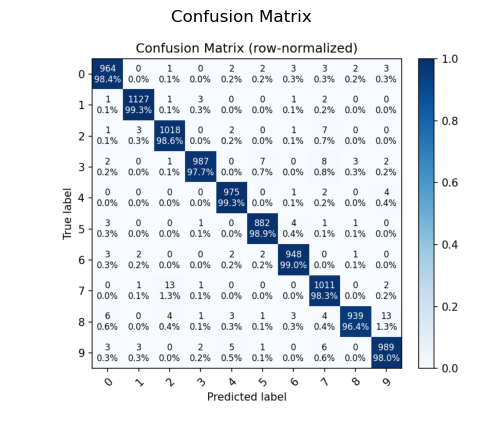

In [6]:
import os
import matplotlib.pyplot as plt

img_path = os.path.join("/Users/saud06/dev/Multiclass-NN-terminal-setup", "artifacts", "confusion_matrix.png")
img = plt.imread(img_path)
plt.figure(figsize=(6,5))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

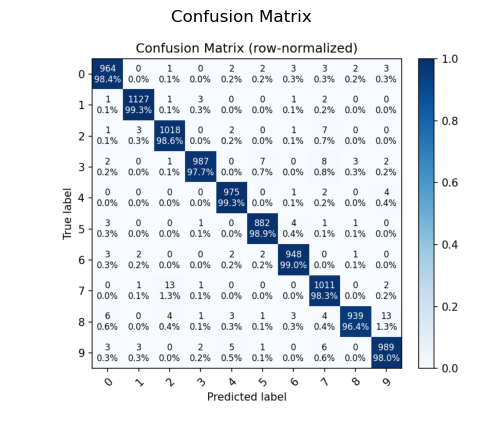

In [7]:
import os
import matplotlib.pyplot as plt
from typing import Optional, Tuple

def display_image_from_path(
    image_path: str, 
    figsize: Tuple[int, int] = (6, 5), 
    title: Optional[str] = None
) -> None:
    """
    Display an image from the specified file path using matplotlib.
    
    Args:
        image_path (str): Path to the image file to be displayed
        figsize (Tuple[int, int], optional): Figure size in inches (width, height). Defaults to (6, 5).
        title (Optional[str], optional): Title to display above the image. Defaults to None.
    
    Returns:
        None: This function displays the image but doesn't return any value
    """
    # Verify the image path exists
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at path: {image_path}")
    
    # Read and display the image
    img = plt.imread(image_path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    
    if title:
        plt.title(title)
    
    plt.show()

# Example usage
img_path = os.path.join("/Users/saud06/dev/Multiclass-NN-terminal-setup", "artifacts", "confusion_matrix.png")
display_image_from_path(img_path, title="Confusion Matrix")